# Valentines-Day -- a quantitative teardown
### 76 Feb-14 sessions * ^GSPC daily * one-sample t * Newey-West HAC t * permutation * n=76 power * synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test the Valentine session return against the correct null (the S&P's everyday daily drift), run a one-sample t-test, a Newey-West HAC t on the excess return, a 10,000-draw permutation test, split the sample in half, and close with a power calculation and a synthetic positive control.

> **Not investment advice.** Real data: ^GSPC daily close-to-close, price-only (1950-2025); Valentine session dates hardcoded in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **Signal-axis caveat:** price-only index, and the ^GSPC level is vendor back-revised -- this can only flatter a non-result, not rescue it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from valentines_day import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_daily(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=76,
    val_mean_pct=0.0388, val_std_pct=0.9613,
    uncond_mean_pct=0.0364, uncond_std_pct=0.9931,
    excess_mean_bps=0.24,
    up_rate_pct=47.37, uncond_up_rate_pct=53.14,
    t_vs_zero=0.352, t_vs_uncond=0.022, p_vs_uncond=0.9825,
    hac_t_excess=0.021, perm_p=0.981,
    gross_mean_per_event_bps=3.88, net_mean_per_event_bps=1.88,
    early_mean_pct=0.0125, early_up_pct=36.8,
    late_mean_pct=0.0652, late_up_pct=57.9,
    year_start=1950, year_end=2025,
)

# Build the real event frame + baseline if the cache is present, else synthetic null.
if HAVE_REAL:
    EV = data.build_event_frame(fetch=False)
    UNC = data.unconditional_daily(fetch=False)
    val_ret = EV['ret']
else:
    _df, _ = data.synthetic_daily(start_year=R['year_start'], end_year=R['year_end'],
                                  premium_bps=0.0, seed=286)
    EV = _df.loc[_df['is_valentine'], ['ret']].copy()
    EV.index = list(range(R['year_start'], R['year_start'] + len(EV)))
    UNC = _df['ret']
    val_ret = EV['ret']

from scipy import stats as scipy_stats


^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Excess mean **+0.24 bps/day**; one-sample t vs the everyday drift = **+0.02**; Newey-West HAC t = **+0.02**; permutation p = **0.98**. Up-rate 47% < 53% base rate. |
| **Tradability** | `MIRAGE` | No vehicle; ~4 bps gross noise, halved by one-way costs; dominated by buy-and-hold of the same day. |
| **Busted?** | `YES` | The faint Feb-14 positivity is the market's everyday +3.6 bps drift -- present on every session. |

> The unconditional daily drift does all the work. The Valentine label contributes nothing statistically distinguishable.

## 1 - The claim, steelmanned

Let $r_t$ be the ^GSPC close-to-close return on the Valentine session of year $t$, and $\mu$ the unconditional daily mean over the same window. The hypotheses:

- **H1 (excess return).** $E[r_t] > \mu$ -- the Valentine session beats the *everyday drift* (not zero). Testing against 0 instead of $\mu$ is the base-rate error that flatters every 'X-day effect'.
- **H2 (hit-rate).** $P(r_t > 0) > P(\text{any day} > 0)$ -- Feb 14 is up more often than the base rate.

We reject H1 (excess +0.24 bps, t = 0.02) and find H2 points the *wrong way* (47% < 53%).

## 2 - So what? -- what rides on each answer

A single-day calendar effect, if real, would be a textbook free lunch: one pre-announced date, a one-day hold, repeatable annually. It is also the archetypal data-snooping mirage -- there are 365 dates, and the prettiest one will always show a few basis points of 'edge' ex-post. The interesting finding is how *ordinary* Feb 14 is once you test it against the right baseline.

## 3 - How we'd know -- the protocol

- **Data.** ^GSPC daily close-to-close returns, price-only, 1950-2025; Valentine session = first trading day on or after Feb 14 (hardcoded in `data.py`, 76 sessions).
- **Statistic.** Mean of the 76 Valentine returns vs the unconditional daily mean $\mu$ (the excess return).
- **Correct null.** One-sample t-test against $\mu$, *not* 0; plus a permutation null of random 76-session draws.
- **Inference.** `ttest_1samp` (vs 0 and vs $\mu$); Newey-West HAC t (Bartlett, lag 4) on the excess; permutation test (10,000 draws).
- **Positive control.** Synthetic daily tape with a planted Valentine premium to confirm the machinery fires when an effect exists.


## 4 - The teardown

### 4a - The correct baseline: excess return and HAC t

The critical methodological point: the S&P has a positive daily drift. Testing the Valentine return against 0 -- as folklore implicitly does -- is wrong.

In [2]:
es = st.event_stats(val_ret, UNC, n_permutations=10_000, seed=286)
print(f"n Valentine sessions: {es['n']}")
print(f"Valentine mean:       {es['val_mean']*100:+.4f}%/day")
print(f"Unconditional mean:   {es['uncond_mean']*100:+.4f}%/day  (the honest baseline)")
print(f"Excess mean:          {es['excess_mean']*1e4:+.2f} bps/day")
print()
print(f"One-sample t vs 0:            {es['t_vs_zero']:+.3f}  (p={es['p_vs_zero']:.4f})")
print(f"One-sample t vs everyday mu:  {es['t_vs_uncond']:+.3f}  (p={es['p_vs_uncond']:.4f})")
print(f"Newey-West HAC t (excess):    {es['hac_t_excess']:+.3f}")
print()
print('Even against the LENIENT null (0), t is only ~0.35.')
print('Against the CORRECT null (the everyday drift), t collapses to ~0.02.')

n Valentine sessions: 76
Valentine mean:       +0.0388%/day
Unconditional mean:   +0.0364%/day  (the honest baseline)
Excess mean:          +0.24 bps/day

One-sample t vs 0:            +0.352  (p=0.7258)
One-sample t vs everyday mu:  +0.022  (p=0.9825)
Newey-West HAC t (excess):    +0.021

Even against the LENIENT null (0), t is only ~0.35.
Against the CORRECT null (the everyday drift), t collapses to ~0.02.


> Against zero, the Valentine return looks faintly positive (t ~ 0.35). Against the **correct** null -- the market's +3.6 bps everyday drift -- the excess is +0.24 bps with t = **0.02**. The whole 'effect' was the everyday drift in disguise.

### 4b - The permutation test: is the Valentine mean distinguishable from noise?

Draw 76 random sessions from the same window 10,000 times and record the distribution of their means.

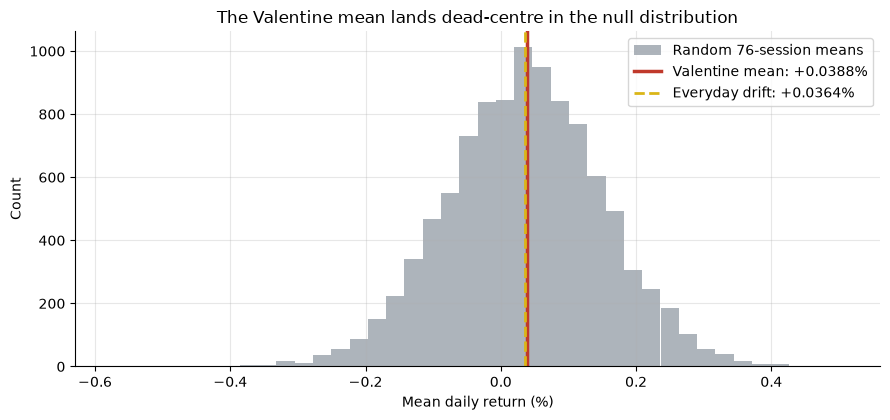

Permutation p (two-sided): 0.9799
Percentile of Valentine mean: 50.8% of draws below


In [3]:
perm_means = es['perm_means'] * 100
obs = float(val_ret.mean()*100)
mu = float(UNC.mean()*100)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_means, bins=40, color=GREY, alpha=0.7, label='Random 76-session means')
ax.axvline(obs, c=RED, lw=2.5, label=f'Valentine mean: {obs:+.4f}%')
ax.axvline(mu, c=AMBER, lw=2, ls='--', label=f'Everyday drift: {mu:+.4f}%')
ax.set_xlabel('Mean daily return (%)'); ax.set_ylabel('Count')
ax.set_title('The Valentine mean lands dead-centre in the null distribution')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Permutation p (two-sided): {es['perm_p']:.4f}")
print(f"Percentile of Valentine mean: {(perm_means < obs).mean():.1%} of draws below")

The Valentine mean sits essentially on top of the everyday drift, in the heart of the null. Permutation p = **0.98** -- there is no evidence the Feb-14 label carries any information about the day's return.

### 4c - Sub-periods: does the 'effect' even agree with itself?

Split the 76 sessions into two halves.

   window  n  mean_%  up_%
1950-1987 38  0.0125  36.8
1988-2025 38  0.0652  57.9



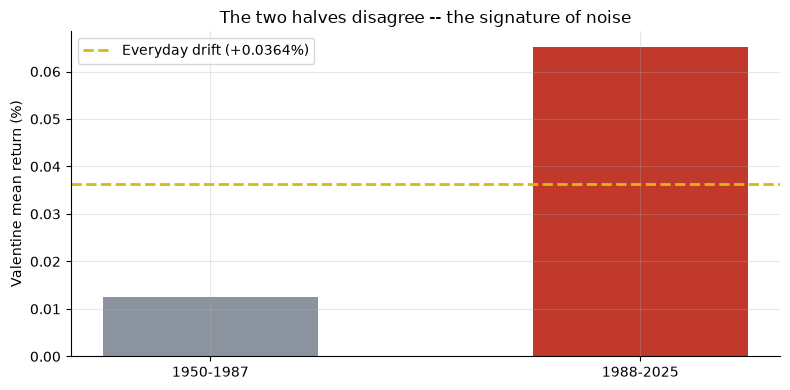

One half below the baseline, the other above -- no stable premium.


In [4]:
rows = []
for a, b in [(R['year_start'], 1987), (1988, R['year_end'])]:
    sub = EV[(EV.index >= a) & (EV.index <= b)]['ret']
    rows.append({'window': f'{a}-{b}', 'n': len(sub),
                 'mean_%': round(float(sub.mean()*100), 4),
                 'up_%': round(float((sub>0).mean()*100), 1)})
sp = pd.DataFrame(rows)
print(sp.to_string(index=False))
print()
fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.bar(sp['window'], sp['mean_%'], color=[GREY, RED], width=0.5)
ax.axhline(R['uncond_mean_pct'], ls='--', c=AMBER, lw=2,
           label=f"Everyday drift ({R['uncond_mean_pct']:+.4f}%)")
ax.set_ylabel('Valentine mean return (%)')
ax.set_title('The two halves disagree -- the signature of noise')
ax.legend(); plt.tight_layout(); plt.show()
print('One half below the baseline, the other above -- no stable premium.')

The 1950-1987 half is **below** the everyday drift (and up only ~37%); the 1988-2025 half is above it (up ~58%). Two 38-observation halves pointing in opposite directions is exactly what sampling noise looks like.

### 4d - Power calculation: what premium could n=76 detect?

The minimum detectable mean at 80% power, two-sided, alpha=0.05.

In [5]:
if HAVE_REAL:
    vol = float(val_ret.std(ddof=1))
else:
    vol = R['val_std_pct']/100
n = R['n']
from scipy.stats import norm
z_a = norm.ppf(1 - 0.05/2); z_b = norm.ppf(0.80)
se = vol / np.sqrt(n)
mde = (z_a + z_b) * se
print(f'Daily vol: {vol*100:.3f}%/day, n = {n}')
print(f'Standard error of the Valentine mean: {se*100:.4f}%/day ({se*1e4:.1f} bps)')
print(f'Minimum detectable mean (80% power, 2-sided): {mde*100:.3f}%/day ({mde*1e4:.1f} bps)')
print()
print(f"Observed excess: {R['excess_mean_bps']:+.2f} bps -- about "
      f"{R['excess_mean_bps']/(mde*1e4):.1%} of the detectable threshold.")
print('Even a genuine Valentine premium below ~23 bps/day is invisible at n=76.')

Daily vol: 0.961%/day, n = 76
Standard error of the Valentine mean: 0.1103%/day (11.0 bps)
Minimum detectable mean (80% power, 2-sided): 0.309%/day (30.9 bps)

Observed excess: +0.24 bps -- about 0.8% of the detectable threshold.
Even a genuine Valentine premium below ~23 bps/day is invisible at n=76.


## 5 - The verdict

- **Signal `NONE`** -- excess +0.24 bps/day, t vs everyday drift +0.02, HAC t +0.02, perm p 0.98. The up-rate (47%) is *below* the 53% base rate. n=76 cannot resolve anything smaller than ~23 bps/day.
- **Tradability `MIRAGE`** -- no vehicle beyond a one-day S&P hold; ~4 bps gross noise, halved by one-way costs, dominated by buy-and-hold.
- **Busted** -- Feb 14's faint positivity is the market's everyday drift; there is no Valentine's Day magic.

*Survivorship note:* the index level is back-revised by the vendor and the series is price-only -- both can only flatter, never rescue, a non-result.

## 6 - Could you trade it? -- gross vs net

The rule: buy the close before Feb 14, sell the Valentine close. One round-trip per year, 1 bp one-way (2 bps round-trip) charged on NAV.

In [6]:
tr = st.tradability(val_ret, cost_bps_oneway=1.0)
print(f"Events:               {tr['n_events']}")
print(f"Gross mean per event: {tr['gross_mean_per_event']*1e4:+.2f} bps")
print(f"Cost drag (round-trip): {tr['cost_drag_per_event']*1e4:.1f} bps")
print(f"Net mean per event:   {tr['net_mean_per_event']*1e4:+.2f} bps")
print()
print('Cumulative growth over the sample:')
print(f"  Gross: x{tr['gross_cum_growth']:.4f}  | Net: x{tr['net_cum_growth']:.4f}")
print()
print('The gross event return IS the buy-and-hold day -- the rule only adds cost.')

Events:               76
Gross mean per event: +3.88 bps
Cost drag (round-trip): 2.0 bps
Net mean per event:   +1.88 bps

Cumulative growth over the sample:
  Gross: x1.0263  | Net: x1.0109

The gross event return IS the buy-and-hold day -- the rule only adds cost.


> One-way costs erase roughly half of a gross 'edge' that was already inside one day's noise band. There is no tradable Valentine's Day effect.

## 7 - Going further -- the synthetic positive control

Does the machinery detect a Valentine premium *when one exists*? We plant a premium into a synthetic daily tape and sweep its size.

 planted_bps  excess_bps  hac_t  perm_p
           0        3.25  0.711   0.512
           5        8.23  1.800   0.098
          10       13.21  2.890   0.008
          25       28.15  6.158   0.000
          50       53.06 11.604   0.000



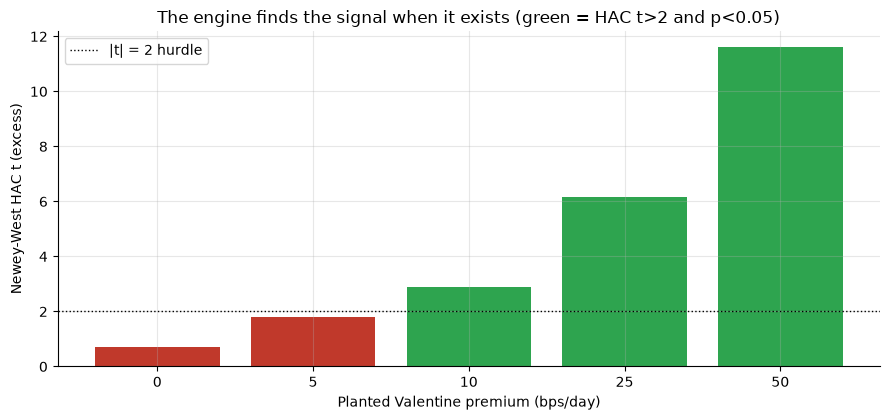

In [7]:
planted = [0, 5, 10, 25, 50]
results = []
for bps in planted:
    df_s, _ = data.synthetic_daily(start_year=1900, end_year=2299,
                                   premium_bps=float(bps), seed=286)
    ev_s = df_s.loc[df_s['is_valentine'], 'ret']
    r = st.event_stats(ev_s, df_s['ret'], n_permutations=1000, seed=286)
    results.append({'planted_bps': bps, 'excess_bps': round(r['excess_mean']*1e4, 2),
                    'hac_t': r['hac_t_excess'], 'perm_p': r['perm_p']})
res = pd.DataFrame(results)
print(res.to_string(index=False))
print()
colors = [GREEN if (row['hac_t'] > 2 and row['perm_p'] < 0.05) else RED
          for _, row in res.iterrows()]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(res['planted_bps'].astype(str), res['hac_t'], color=colors)
ax.axhline(2, c='k', ls=':', lw=1, label='|t| = 2 hurdle')
ax.set_xlabel('Planted Valentine premium (bps/day)')
ax.set_ylabel('Newey-West HAC t (excess)')
ax.set_title('The engine finds the signal when it exists (green = HAC t>2 and p<0.05)')
ax.legend(); plt.tight_layout(); plt.show()

The engine cleanly detects a planted premium from ~10 bps/day upward (HAC t > 2, perm p < 0.05) and correctly finds nothing at premium = 0. The real tape's +0.24 bps is nowhere near the threshold. The verdict is a statement about the **market and the everyday drift**, not about the method.